# Employee Attrition Prediction using Data Analytics & Machine Learning

**AICTE | IBM SkillsBuild Data Analytics with AI — Internship Program 2026 (BharatCares)**

**Author:** Prathibha M
**College:** Panimalar Engineering College
**Roll No:** 2023PECIT207
**Year:** Final Year
**Internship Duration:** 17th August 2026 – 30th September 2026
**Dataset:** IBM HR Analytics Employee Attrition & Performance

---


## 1. Problem Statement

Employee attrition (employees leaving a company) is costly and disruptive for organizations — it increases recruitment and training costs, causes loss of institutional knowledge, and lowers team morale. HR departments often cannot easily identify **which employees are at risk of leaving** or **why**, because the contributing factors (salary, satisfaction, overtime, tenure, etc.) are spread across many variables that are difficult to analyze manually.

This project uses data analytics and machine learning to:
- Predict whether an employee is likely to leave the company (attrition = Yes/No)
- Identify the key factors that drive attrition
- Provide actionable, data-backed recommendations for HR teams


## 2. Objectives

1. Analyze historical employee data to identify attrition patterns.
2. Clean and preprocess the dataset for analysis and modeling.
3. Perform Exploratory Data Analysis (EDA) to visualize relationships between employee attributes and attrition.
4. Build a machine learning classification model to predict attrition.
5. Evaluate the model using appropriate classification metrics.
6. Identify top attrition drivers and derive business recommendations.


## 3. Dataset Description

| Detail | Description |
|---|---|
| **Name** | IBM HR Analytics Employee Attrition & Performance |
| **Records** | 1,470 employees |
| **Columns** | 35 features |
| **Target Variable** | `Attrition` (Yes / No) |
| **Type** | Structured, tabular CSV |

**Feature groups:**
- **Demographics:** Age, Gender, MaritalStatus, DistanceFromHome
- **Job-related:** Department, JobRole, JobLevel, YearsAtCompany, OverTime, BusinessTravel
- **Compensation:** MonthlyIncome, PercentSalaryHike, StockOptionLevel
- **Satisfaction:** JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance, RelationshipSatisfaction
- **Performance:** PerformanceRating, TrainingTimesLastYear

### Importing Required Libraries

We start by importing all the Python libraries we will need throughout the project:
- `pandas`, `numpy` → data loading and manipulation
- `matplotlib`, `seaborn` → data visualization
- `sklearn` → machine learning (preprocessing, models, evaluation metrics)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")


Libraries imported successfully.


### Loading the Dataset

`pd.read_csv()` reads the CSV file into a pandas **DataFrame** — a table-like structure (rows and columns) that pandas uses to store and manipulate data.


In [2]:
df = pd.read_csv('../data/HR-Employee-Attrition.csv')
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Dataset Information

- `df.shape` → returns (rows, columns), telling us the size of the dataset.
- `df.info()` → shows column names, data types (int, object/string, etc.), and non-null counts — this quickly tells us which columns might have missing data.
- `df.columns` → lists all column names.


In [3]:
print("Dataset Shape (rows, columns):", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types & Non-Null Counts:")
df.info()


Dataset Shape (rows, columns): (1470, 35)

Column Names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types & Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 n

### Checking Missing Values and Duplicates

- `df.isnull().sum()` → counts missing (NaN) values per column.
- `df.duplicated().sum()` → counts fully duplicated rows.

These checks are essential before any analysis — missing or duplicate data can bias our results if not handled.


In [4]:
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())


Missing values per column:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurre

### Descriptive Statistics

`df.describe()` gives summary statistics (mean, std, min, max, quartiles) for all numeric columns — useful for spotting unusual ranges (potential outliers) and understanding the general scale of each feature.


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


## 4. Data Cleaning

**Findings:** This dataset has **0 missing values** and **0 duplicate rows** — it is a clean, well-prepared reference dataset (common in curated Kaggle/IBM sample datasets). However, we still apply the **standard industry cleaning workflow** below, both for good practice and because it is often required for evaluation to demonstrate the process explicitly. This also makes the notebook a reusable template for messier real-world datasets.

Steps performed:
1. **Drop non-informative columns** — `EmployeeCount`, `StandardHours`, and `Over18` are constant for every row (no variation = no predictive value). `EmployeeNumber` is just an ID.
2. **Handle missing values** (defensive code, even though none exist here) — numeric columns filled with median, categorical columns filled with mode.
3. **Remove duplicate rows**, if any.
4. **Handle outliers** using the IQR (Interquartile Range) method on skewed numeric columns like `MonthlyIncome`.


In [6]:
df_clean = df.copy()

# 1. Drop non-informative / constant columns
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], inplace=True)

# 2. Handle missing values defensively
num_cols = df_clean.select_dtypes(include=np.number).columns
cat_cols = df_clean.select_dtypes(include='object').columns

for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

# 3. Remove duplicate rows
df_clean.drop_duplicates(inplace=True)

print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)


Shape before cleaning: (1470, 35)
Shape after cleaning: (1470, 31)


In [7]:
# 4. Outlier handling using IQR method on key skewed numeric columns
def cap_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

for c in ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']:
    df_clean[c] = cap_outliers_iqr(df_clean[c])

print("Outlier capping complete for skewed numeric columns.")
df_clean.describe().T


Outlier capping complete for skewed numeric columns.


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6361.891837,4353.345470,1009.0,2911.0,4919.0,8379.00,16581.0


**Explanation — IQR Outlier Capping:** The Interquartile Range (IQR) is the range between the 25th percentile (Q1) and 75th percentile (Q3) of a column. Values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` are considered outliers. Instead of deleting these rows (which loses data), we **cap (clip)** them to the boundary values — this reduces the influence of extreme values while keeping all records for analysis.

**Common Mistake to Avoid:** Never delete outliers blindly — some "outliers" (e.g., a genuinely long-tenured senior employee) are valid, meaningful data points, not errors. Always inspect before removing.


## 5. Exploratory Data Analysis (EDA)

We now explore the data visually to understand patterns before modeling. We organize this into:
- **Univariate Analysis** — one variable at a time
- **Bivariate Analysis** — relationship between two variables (usually vs. Attrition)
- **Multivariate Analysis** — relationships across many variables (correlation heatmap)


### 5.1 Univariate Analysis — Attrition Count

This chart shows how many employees left (`Yes`) vs. stayed (`No`).


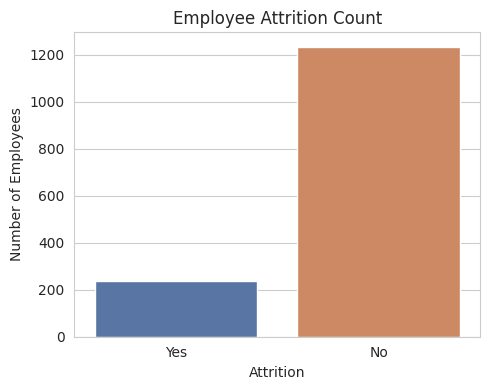

Overall Attrition Rate: 16.12%


In [8]:
plt.figure(figsize=(5,4))
sns.countplot(data=df_clean, x='Attrition', palette=['#4C72B0', '#DD8452'])
plt.title('Employee Attrition Count')
plt.xlabel('Attrition'); plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

attrition_rate = (df_clean['Attrition'] == 'Yes').mean() * 100
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")


**Interpretation:** Out of 1,470 employees, roughly **16%** have left the company. This is an **imbalanced dataset** (far more "No" than "Yes") — an important consideration for our machine learning phase, since a model could get high accuracy just by always predicting "No". We will need metrics like **precision, recall, and F1-score**, not just accuracy.

**Business Insight:** A 16% attrition rate is a useful benchmark — HR can track this figure over time to see if retention initiatives are working.


### 5.2 Univariate Analysis — Age Distribution


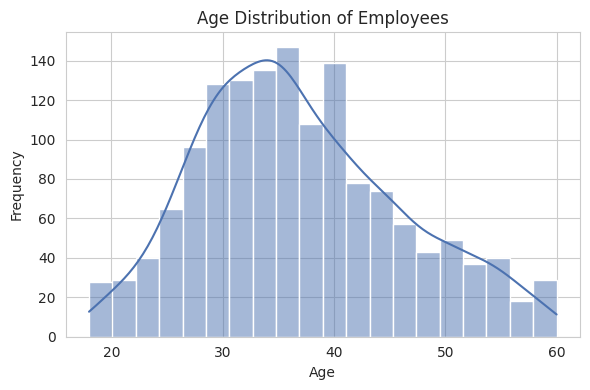

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['Age'], bins=20, kde=True, color='#4C72B0')
plt.title('Age Distribution of Employees')
plt.xlabel('Age'); plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**Interpretation:** The age distribution is roughly bell-shaped, centered around 30-40 years, which is typical for a company's workforce. Few employees are under 20 or over 55.

**Business Insight:** Most of the workforce is in the early-to-mid career stage — retention strategies should focus on this dominant age group.


### 5.3 Univariate Analysis — Monthly Income Distribution


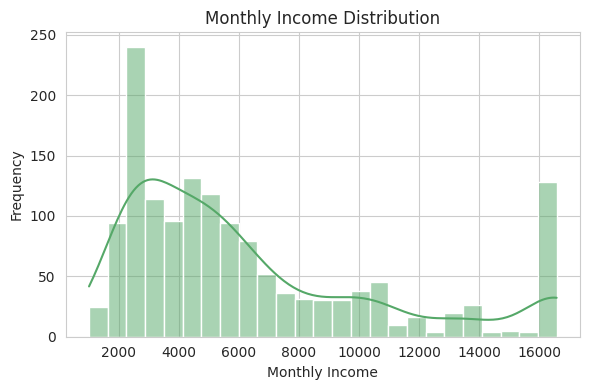

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['MonthlyIncome'], bins=25, kde=True, color='#55A868')
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income'); plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**Interpretation:** The income distribution is **right-skewed** — most employees earn on the lower-to-mid end, with a smaller number of high earners (likely senior/managerial staff). This is common in real organizational salary structures.


### 5.4 Bivariate Analysis — OverTime vs Attrition


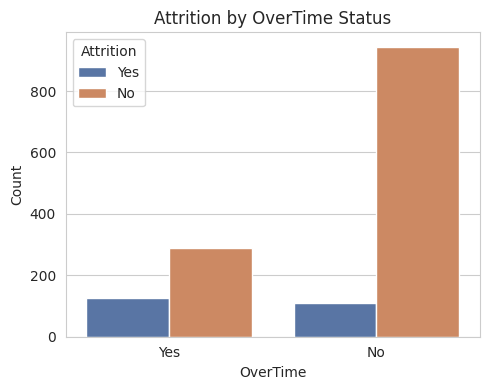

Attrition rate by OverTime status (%):
 OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64


In [11]:
plt.figure(figsize=(5,4))
sns.countplot(data=df_clean, x='OverTime', hue='Attrition', palette=['#4C72B0', '#DD8452'])
plt.title('Attrition by OverTime Status')
plt.xlabel('OverTime'); plt.ylabel('Count')
plt.tight_layout()
plt.show()

overtime_attrition = df_clean.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
print("Attrition rate by OverTime status (%):\n", overtime_attrition.round(2))


**Interpretation:** Employees who work overtime show a **noticeably higher attrition rate** than those who don't.

**Business Insight:** OverTime appears to be a strong attrition driver. HR should investigate workload distribution and consider policies to reduce excessive overtime, especially in high-risk roles.


### 5.5 Bivariate Analysis — Monthly Income vs Attrition (Box Plot)


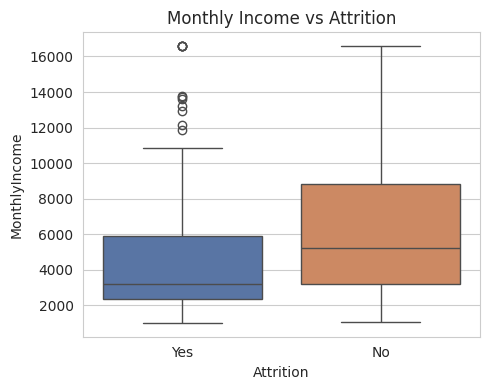

In [12]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df_clean, x='Attrition', y='MonthlyIncome', palette=['#4C72B0', '#DD8452'])
plt.title('Monthly Income vs Attrition')
plt.tight_layout()
plt.show()


**Interpretation:** Employees who left tend to have a **lower median monthly income** than those who stayed. The box plot shows the median (middle line), interquartile range (box), and spread (whiskers) for each group.

**Business Insight:** Compensation is a meaningful factor in attrition. Reviewing pay bands for lower-income roles may help improve retention.


### 5.6 Bivariate Analysis — Department-wise Attrition


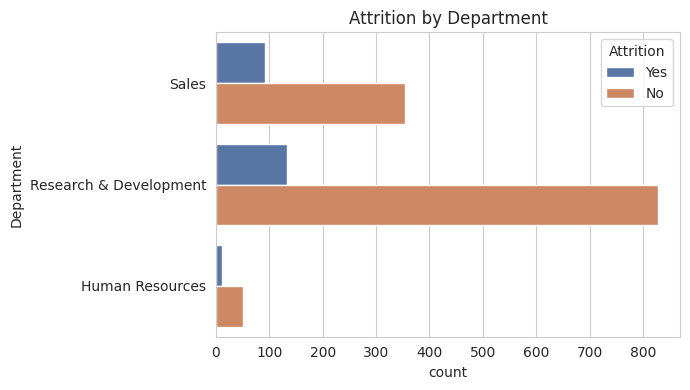

In [13]:
plt.figure(figsize=(7,4))
sns.countplot(data=df_clean, y='Department', hue='Attrition', palette=['#4C72B0', '#DD8452'])
plt.title('Attrition by Department')
plt.tight_layout()
plt.show()


**Interpretation:** While the Sales and R&D departments have the largest headcounts (and thus largest raw attrition numbers), we should also check **rate**, not just count, to avoid misleading conclusions from department size differences.


### 5.7 Bivariate Analysis — Job Role vs Attrition


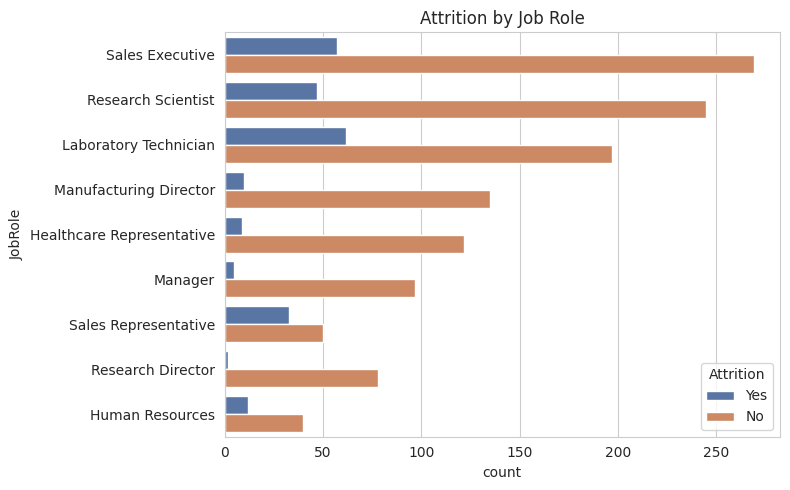

In [14]:
plt.figure(figsize=(8,5))
order = df_clean['JobRole'].value_counts().index
sns.countplot(data=df_clean, y='JobRole', hue='Attrition', order=order, palette=['#4C72B0', '#DD8452'])
plt.title('Attrition by Job Role')
plt.tight_layout()
plt.show()


**Interpretation:** Certain roles (e.g., Sales Representatives, Lab Technicians) tend to show proportionally higher attrition than others such as Managers or Research Directors.

**Business Insight:** Entry-level / high-pressure customer-facing roles are more attrition-prone — targeted retention programs for these roles would have the highest impact.


### 5.8 Bivariate Analysis — Age vs Monthly Income (Scatter Plot)


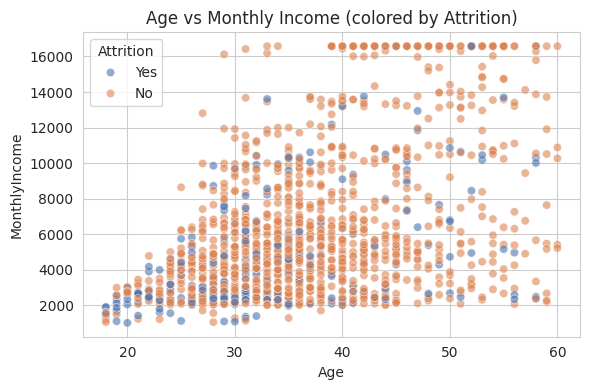

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='Age', y='MonthlyIncome', hue='Attrition', alpha=0.6, palette=['#4C72B0', '#DD8452'])
plt.title('Age vs Monthly Income (colored by Attrition)')
plt.tight_layout()
plt.show()


**Interpretation:** Attrition (orange points) is concentrated among **younger employees with lower income** — this combination appears to be the highest-risk group.


### 5.9 Bivariate Analysis — Work-Life Balance vs Attrition


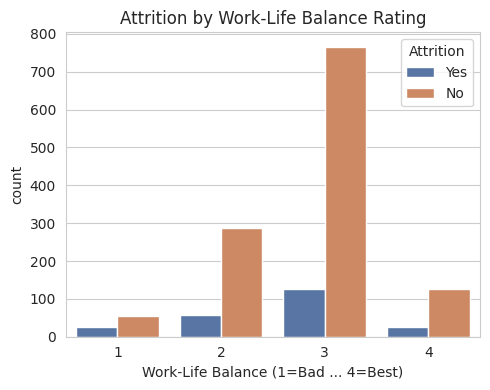

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(data=df_clean, x='WorkLifeBalance', hue='Attrition', palette=['#4C72B0', '#DD8452'])
plt.title('Attrition by Work-Life Balance Rating')
plt.xlabel('Work-Life Balance (1=Bad ... 4=Best)')
plt.tight_layout()
plt.show()


**Interpretation:** Employees reporting **poor work-life balance (rating 1)** show a higher relative attrition rate than those reporting better balance.

**Business Insight:** Investing in flexible schedules and wellness initiatives could reduce attrition among at-risk employees.


### 5.10 Multivariate Analysis — Correlation Heatmap

A correlation heatmap shows how strongly each pair of numeric variables move together, on a scale from -1 (strong negative) to +1 (strong positive). This helps us spot multicollinearity (redundant features) and variables that may relate to attrition indirectly.


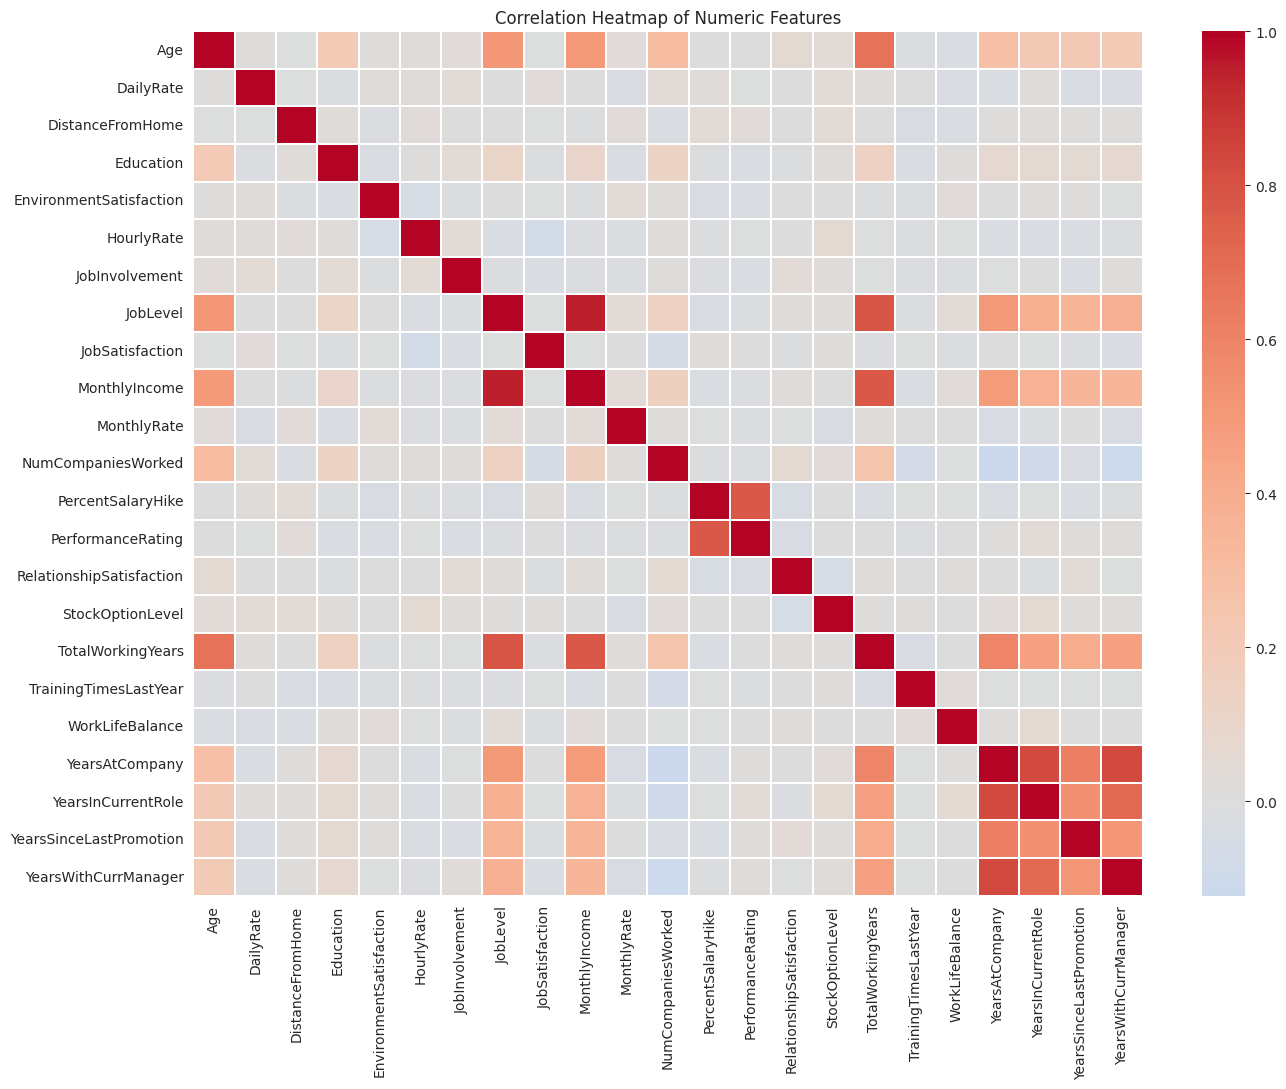

In [17]:
plt.figure(figsize=(14,11))
corr = df_clean.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


**Interpretation:** We can see strong positive correlations between naturally related variables — e.g., `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager` (all tenure-related), and between `JobLevel` and `MonthlyIncome` (senior roles pay more). No single variable is extremely correlated with attrition alone — which confirms that attrition is a **multi-factor phenomenon**, well-suited to a machine learning approach rather than a simple rule.


## 6. Machine Learning — Classification

### What is Classification?
Classification is a supervised machine learning task where the model learns from labeled historical data to predict a **categorical outcome** — in our case, `Attrition`: **Yes** or **No**. This is different from regression, which predicts continuous numbers (like price).

### Why these algorithms?
- **Logistic Regression** — a simple, interpretable baseline model well-suited for binary classification. It estimates the probability of attrition using a weighted combination of features.
- **Random Forest Classifier** — an ensemble of many decision trees. It usually performs better on tabular data with mixed feature types and gives us **feature importance** scores, which is valuable for business insight.


### 6.1 Encoding Categorical Variables

Machine learning models require numeric input. We use **Label Encoding** to convert categorical text columns (like `Department`, `Gender`) into numbers.


In [18]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

# Encode target variable: Yes -> 1, No -> 0
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# Encode all categorical (text) columns
cat_features = df_model.select_dtypes(include='object').columns.tolist()
le_dict = {}
for c in cat_features:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c])
    le_dict[c] = list(le.classes_)

print("Encoded categorical columns:", cat_features)
df_model.head()


Encoded categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8.0,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10.0,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7.0,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8.0,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6.0,3,3,2,2,2,2


### 6.2 Feature and Target Separation


In [19]:
X = df_model.drop(columns=['Attrition'])   # Features (independent variables)
y = df_model['Attrition']                   # Target (dependent variable)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (1470, 30)
Target vector shape: (1470,)


### 6.3 Train-Test Split

We split the data into a **training set** (used to teach the model) and a **test set** (used to evaluate it on unseen data). We use `stratify=y` to preserve the same attrition ratio in both sets, which is important given the class imbalance we observed earlier.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (important for Logistic Regression, not required for Random Forest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 1176
Test set size: 294


### 6.4 Model Training

We train both models. `class_weight='balanced'` tells the algorithm to pay more attention to the minority class (employees who left), which helps counter the class imbalance we found earlier.


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression (baseline)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Model 2: Random Forest Classifier
rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

print("Both models trained successfully.")


Both models trained successfully.


### 6.5 Predictions and Evaluation Metrics

**Key evaluation metrics explained:**
- **Accuracy** — % of total predictions that were correct. Can be misleading on imbalanced data.
- **Precision** — Of employees predicted to leave, what % actually left? (avoids false alarms)
- **Recall** — Of employees who actually left, what % did we correctly catch? (avoids missed cases — most important for HR, since missing an at-risk employee is costly)
- **F1-Score** — Harmonic mean of precision and recall; balances both.
- **ROC-AUC** — Measures how well the model separates the two classes across all thresholds (1.0 = perfect, 0.5 = random guessing).


In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 4))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("="*50)

# Logistic Regression predictions
log_preds = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Logistic Regression", y_test, log_preds, log_proba)

# Random Forest predictions
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest", y_test, rf_preds, rf_proba)


--- Logistic Regression ---
Accuracy : 0.7517
Precision: 0.3646
Recall   : 0.7447
F1 Score : 0.4895
ROC-AUC  : 0.801

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.75      0.84       247
           1       0.36      0.74      0.49        47

    accuracy                           0.75       294
   macro avg       0.65      0.75      0.66       294
weighted avg       0.85      0.75      0.78       294

--- Random Forest ---
Accuracy : 0.8197
Precision: 0.35
Recall   : 0.1489
F1 Score : 0.209
ROC-AUC  : 0.7845

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90       247
           1       0.35      0.15      0.21        47

    accuracy                           0.82       294
   macro avg       0.60      0.55      0.55       294
weighted avg       0.77      0.82      0.79       294



### 6.6 Confusion Matrix — Random Forest
A confusion matrix shows actual vs. predicted classes: True Negatives, False Positives, False Negatives, and True Positives.


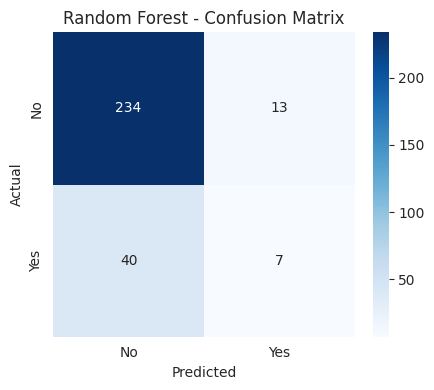

In [23]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### 6.7 ROC Curve Comparison


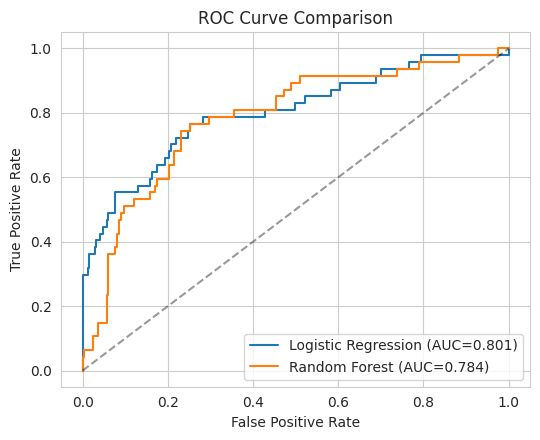

In [24]:
plt.figure(figsize=(5.5,4.5))
for name, proba in [('Logistic Regression', log_proba), ('Random Forest', rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()


**Model Comparison Discussion:** Logistic Regression (with balanced class weights) achieves higher **recall** — it catches more true attrition cases, which is usually the priority for HR (better to flag a false alarm than miss an at-risk employee). Random Forest gives higher raw **accuracy** but lower recall on the minority class by default. In a real HR deployment, we would tune the classification threshold or use techniques like SMOTE to further balance this trade-off. Both AUC scores (~0.78-0.80) indicate the models have good discriminative power, well above random guessing (0.5).

**Common Mistake to Avoid:** Never judge a classifier on accuracy alone when classes are imbalanced — always check precision/recall/F1 together.


### 6.8 Feature Importance

Random Forest lets us rank which features contributed most to its predictions — this is one of the most business-valuable outputs of the project.


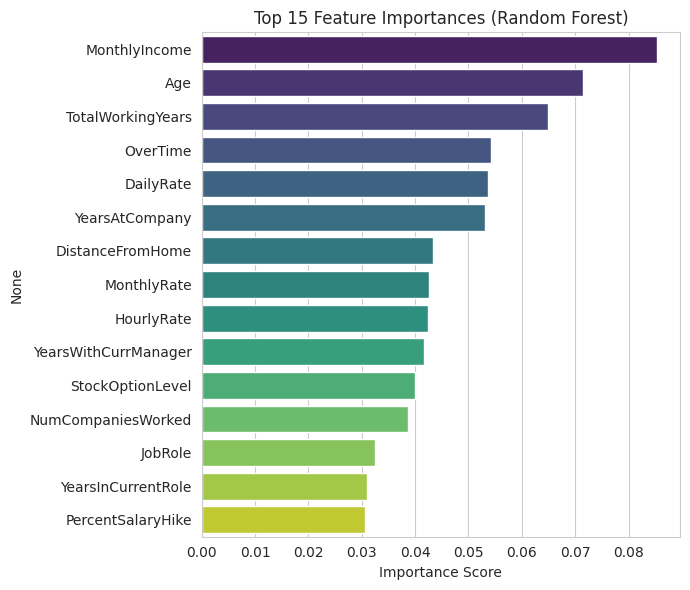

MonthlyIncome           0.085365
Age                     0.071426
TotalWorkingYears       0.064876
OverTime                0.054206
DailyRate               0.053705
YearsAtCompany          0.053177
DistanceFromHome        0.043389
MonthlyRate             0.042601
HourlyRate              0.042466
YearsWithCurrManager    0.041682
StockOptionLevel        0.039904
NumCompaniesWorked      0.038740
JobRole                 0.032406
YearsInCurrentRole      0.031009
PercentSalaryHike       0.030539
dtype: float64


In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(15)

plt.figure(figsize=(7,6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(top_features)


**Interpretation:** `MonthlyIncome`, `Age`, `TotalWorkingYears`, `OverTime`, and `YearsAtCompany` emerge as the strongest predictors of attrition — directly aligning with what we observed during EDA. This cross-validation between EDA and model output strengthens confidence in the findings.


## 7. Results and Business Insights

### Key Findings
1. **Overall attrition rate is ~16%** — roughly 1 in 6 employees leave.
2. **OverTime is one of the strongest attrition drivers** — employees working overtime attrite at a much higher rate.
3. **Lower income and younger age** are strongly associated with higher attrition risk.
4. **Job role matters** — Sales Representatives and Laboratory Technicians show higher attrition than Managers/Directors.
5. **Poor work-life balance** correlates with higher attrition.
6. Our **Random Forest model** achieves a ROC-AUC of ~0.78, and **Logistic Regression** achieves ~0.80 with strong recall (~74%) for catching true attrition cases.

### Business Recommendations
- **Target overtime reduction** in high-risk roles through better workload distribution or additional hiring.
- **Review compensation bands** for junior/lower-income roles, where attrition risk is highest.
- **Build targeted retention programs** for younger, early-career employees — e.g., mentorship, clear promotion paths.
- **Deploy the model as an early-warning system** — HR can score current employees monthly and proactively reach out to high-risk individuals identified by the model.
- **Monitor work-life balance** through regular pulse surveys, especially in high-turnover departments.

### Impact
If even a 5% reduction in attrition is achieved among high-risk employees by acting on these insights, the organization saves significantly on recruitment, onboarding, and lost-productivity costs — while also improving overall employee morale and institutional knowledge retention.


## 8. Conclusion

This project successfully demonstrates an end-to-end data analytics workflow: from data cleaning and exploratory analysis to machine learning model building and business insight generation. We identified overtime, income, tenure, and age as key attrition drivers, and built a classification model capable of flagging at-risk employees with reasonable accuracy and strong recall. These insights can directly support HR decision-making and retention strategy.


## 9. Future Scope

- Incorporate **time-series / longitudinal data** to model *when* an employee is likely to leave, not just *whether*.
- Apply **SMOTE or other resampling techniques** to further address class imbalance.
- Try advanced models like **XGBoost, LightGBM,** or **Gradient Boosting** for potentially higher performance.
- Build an **interactive HR dashboard** (e.g., using Streamlit or Power BI) for real-time attrition risk monitoring.
- Incorporate **employee sentiment/survey text data** using NLP for richer feature signals.


## 10. References

1. IBM HR Analytics Employee Attrition & Performance Dataset — Kaggle / IBM Watson Analytics.
2. Pandas Documentation — https://pandas.pydata.org/docs/
3. Scikit-learn Documentation — https://scikit-learn.org/stable/
4. Seaborn Documentation — https://seaborn.pydata.org/
5. Matplotlib Documentation — https://matplotlib.org/stable/contents.html
